## AOPC plot across all models and datasets

In [1]:
import torch
import os 
import sys
sys.path.append(os.path.join(os.getcwd(), 'src'))
from graphLoader import GraphLoader
from torch_geometric.nn import SAGEConv, GCNConv, GATConv
from torch import nn
import torch.nn.functional as F
from torch.nn import Linear
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

In [2]:
class GATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout)
        self.out = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeddings=False):
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        embeddings = x
        out = self.out(embeddings)
        return embeddings if return_embeddings else out
 
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.out = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        embeddings = F.relu(x) 
        
        out = self.out(embeddings)
        
        if return_embeddings:
            return embeddings
        return out

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.out = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeddings=False):
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)

        embeddings = x
        out = self.out(x)

        if return_embeddings:
            return embeddings

        return out  
    
class GCN_PPI(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels) 
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels) 
        self.out = torch.nn.Linear(hidden_channels, 2)

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)  
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        embeddings = x 
        if return_embeddings:
            return embeddings
        logits = self.out(embeddings)
        return logits
    
class GAT_PPI(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, heads=4):
        super().__init__()
    
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, concat=False)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels) 
        
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=heads, concat=False)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels) 
    
        self.out = torch.nn.Linear(hidden_channels, 2)

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)   
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training) 
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        embeddings = x 
        
        if return_embeddings:
            return embeddings

        logits = self.out(embeddings)
        return logits
class GraphSAGE_PPI(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='mean')
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        
        self.conv2 = SAGEConv(hidden_channels, hidden_channels, aggr='mean')
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.out = torch.nn.Linear(hidden_channels, 2)

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        
        embeddings = x
        if return_embeddings:
            return embeddings

        logits = self.out(embeddings)
        return logits

In [3]:
def most_frequent(values):
    values = values.astype(int)  
    return np.bincount(values).argmax()

def compute_aopc_global(dataset, model, graph, feature_ranking, K):
    """
    Compute AOPC global for a GCN model.
    """
    device = next(model.parameters()).device  
    model.eval()  

    X = graph.x.clone().to(device)  
    edge_index = graph.edge_index.to(device)  

    N = X.shape[0]  
    cumulative_diffs = np.zeros(N)  
    with torch.no_grad():
        orig_probs = model(X, edge_index)  
        pred_classes = orig_probs.argmax(dim=1)    
        orig_class_probs = orig_probs[torch.arange(N), pred_classes].cpu().numpy()
         
    for k in range(K + 1):
        X_modified = X.clone()

        if k > 0:
            features_to_remove = feature_ranking[:k]
            for feature in features_to_remove:
                feature_agg_value = most_frequent(X[:, feature].cpu().numpy())  
                X_modified[:, feature] = feature_agg_value  

        with torch.no_grad():
            new_probs = model(X_modified, edge_index)
            new_class_probs = new_probs[torch.arange(N), pred_classes].cpu().numpy()

        cumulative_diffs += (orig_class_probs - new_class_probs)
        
   
    aopc = np.mean(cumulative_diffs) / (K + 1)
    return aopc

def plot_aopc_global_gcn(model, graph, experiments, K_max, random_runs=5):
    """
    Plot AOPC global curves for different feature ranking methods for a GCN model.

    """
    device = next(model.parameters()).device
    plt.figure(figsize=(10, 6))
    
    for method_name, feature_ranking in experiments.items():
        aopc_values = []
        for k in tqdm(range(K_max + 1), desc=f"Computing {method_name}"):
            aopc = compute_aopc_global(model, graph, feature_ranking, k)
            aopc_values.append(aopc)
        
        plt.plot(range(K_max + 1), aopc_values, label=method_name, marker='o')
    
  
    random_curves = []
    num_features = graph.x.shape[1]
    for _ in range(random_runs):
        ranking = np.random.permutation(num_features).tolist()
        
        aopc_values = []
        for k in tqdm(range(K_max + 1), desc="Computing Random baseline"):
            aopc = compute_aopc_global(model, graph, ranking, k)
            aopc_values.append(aopc)
        random_curves.append(aopc_values)
    
    random_mean = np.mean(random_curves, axis=0)
    random_std = np.std(random_curves, axis=0)
    
    plt.plot(range(K_max + 1), random_mean, label='Random', linestyle='--', color='gray')
    plt.fill_between(range(K_max + 1), random_mean - random_std, random_mean + random_std, color='gray', alpha=0.2)
    
    plt.xlabel('Number of Features Removed (K)', fontsize=25)
    plt.ylabel('AOPC Global', fontsize=25)
    plt.tick_params(axis='x', labelsize=25)
    plt.tick_params(axis='y', labelsize=25)
    plt.legend()
    plt.grid(True)
    plt.savefig(f'AOPC_{graph_dataset_name}_{embedding_method}_{embedding_dimension}_{problem}_.pdf', format='pdf', bbox_inches='tight')
    plt.show()


In [4]:
datasets = ["Cora","CiteSeer", "Pubmed", "PPI"]
embedding_methods = ["GCN", "GAT", "GraphSage"]
explainability_methods = ["TACENR", "GraphLIME", "GNNExplainer", "GraphSVX", "COMPINEX"]

experiments = {}
folder_name = "FeatureRankingsAOPC"
embedding_dimension = 64
 

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
for graph_dataset_name in datasets:
    for embedding_method in embedding_methods:
        key = f"{graph_dataset_name}_{embedding_method}"

        graph_file_path = f'data/{graph_dataset_name}/{graph_dataset_name}_combined.txt'
        graphLoader = GraphLoader(graph_file_path, graph_dataset_name)
        G_nx, G_pyg = graphLoader.load_graph()
        if key not in experiments:
            experiments[key] = {}
        num_classes = torch.unique(G_pyg.y).numel()
        graph = G_pyg
        for explainability_method in explainability_methods:
            ranking_path = os.path.join(folder_name, f"feature_ranking_{graph_dataset_name}_{embedding_method}_{explainability_method}.txt")
            with open(ranking_path, "r") as f:
                feature_ranking = [int(line.strip()) for line in f]
                experiments[key][explainability_method] = [f for f in feature_ranking]
    

NetworkX - Number of nodes: 2485
NetworkX - Number of edges: 5069
NetworkX graph is undirected.
NetworkX graph is connected: True
Number of graphs: 6
PyG - Number of features per node: 1433
Number of classes: 7
PyG - Number of nodes: 2485
PyG - Number of edges: 10138
Is undirected: True
PyG - Number of features per node: 1433
NetworkX - Number of nodes: 2485
NetworkX - Number of edges: 5069
NetworkX graph is undirected.
NetworkX graph is connected: True
Number of graphs: 6
PyG - Number of features per node: 1433
Number of classes: 7
PyG - Number of nodes: 2485
PyG - Number of edges: 10138
Is undirected: True
PyG - Number of features per node: 1433
NetworkX - Number of nodes: 2485
NetworkX - Number of edges: 5069
NetworkX graph is undirected.
NetworkX graph is connected: True
Number of graphs: 6
PyG - Number of features per node: 1433
Number of classes: 7
PyG - Number of nodes: 2485
PyG - Number of edges: 10138
Is undirected: True
PyG - Number of features per node: 1433
NetworkX - Numbe

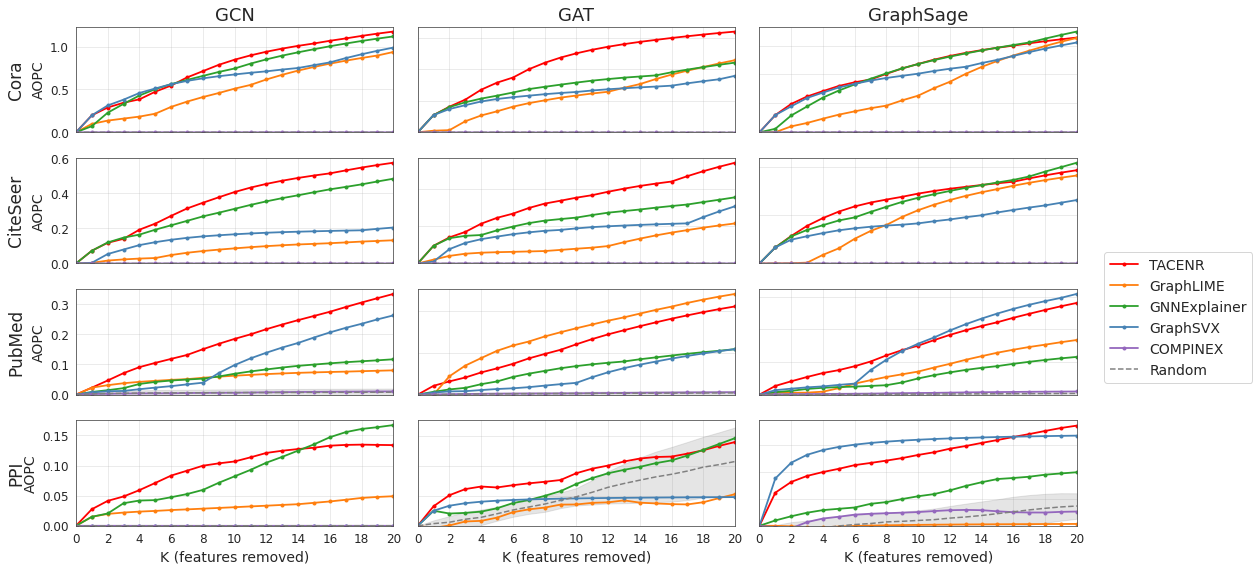

In [ ]:
def plot_aopc_grid_all_models(
    datasets, 
    embedding_methods, 
    experiments, 
    K_max=40, 
    random_runs=5, 
    embedding_dimension=64
):
     
    
    sns.set_style("whitegrid", {
        "axes.facecolor": "#FFFFFF",
        "grid.color": "#B0B0B0",
        "axes.edgecolor": "#4D4D4D",
    })
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 18,
        'legend.fontsize': 12,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12
    })

    n_rows = len(datasets)
    n_cols = len(embedding_methods)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 9),
        sharex=False,
        sharey=False,
        squeeze=False
    )

    os.makedirs("AOPC_cache", exist_ok=True)

    method_colors = {
        "TACENR": "red",
        "GraphLIME": "C1",
        "GNNExplainer": "C2",
        "GraphSVX": "#4682B4",   
        "COMPINEX": "C4"
    }

    for i, dataset in enumerate(datasets):                      
        for j, embedding_method in enumerate(embedding_methods):  
            ax = axes[i][j]
            key = f"{dataset}_{embedding_method}"
            
            if key not in experiments:
                ax.set_visible(False)
                continue

            graph_file_path = f'data/{dataset}/{dataset}_combined.txt'
            graphLoader = GraphLoader(graph_file_path, dataset)
            G_nx, G_pyg = graphLoader.load_graph()
            graph = G_pyg
            num_classes = torch.unique(graph.y).numel()

            if embedding_method == "GCN":
                if dataset == "PPI":
                    model = GCN_PPI(
                        in_channels=graph.num_features,
                        hidden_channels=embedding_dimension
                    )
                else:
                    model = GCN(
                        in_channels=graph.num_features,
                        hidden_channels=embedding_dimension,
                        out_channels=num_classes
                    )
            elif embedding_method == "GAT":
                if dataset == "PPI":
                    model = GAT_PPI(
                        in_channels=graph.num_features,
                        hidden_channels=embedding_dimension
                    )
                else:
                    model = GATModel(
                        in_channels=graph.num_features,
                        hidden_channels=embedding_dimension,
                        out_channels=num_classes
                    )
            elif embedding_method == "GraphSage":
                if dataset == "PPI":
                    model = GraphSAGE_PPI(
                        in_channels=graph.num_features,
                        hidden_channels=embedding_dimension
                    )
                else:
                    model = GraphSAGE(
                        in_channels=graph.num_features,
                        hidden_channels=embedding_dimension,
                        out_channels=num_classes
                    )

            model_path = f"AOPC_saved_models/{dataset}_{embedding_method}.pth"
            if os.path.exists(model_path):
                model.load_state_dict(torch.load(model_path, map_location=device))
            model.eval()

            experiment = experiments[key]

            for k, (method_name, feature_ranking) in enumerate(experiment.items()):
                cache_path = f"AOPC_cache/{dataset}_{embedding_method}_{method_name}_K{K_max}.npy"

                if os.path.exists(cache_path):
                    aopc_values = np.load(cache_path)
                else:
                    aopc_values = []
                    for kk in tqdm(range(K_max + 1), desc=f"{method_name} - {key}"):
                        aopc = compute_aopc_global(
                            model, graph, feature_ranking, kk
                        )
                        aopc_values.append(aopc)

                    aopc_values = np.array(aopc_values)
                    np.save(cache_path, aopc_values)

                ax.plot(
                    range(K_max + 1),
                    aopc_values,
                    label=method_name,
                    color=method_colors.get(method_name, "black"),
                    marker='o',
                    markersize=3,
                    linewidth=1.8
                )

            cache_random_path = (
                f"AOPC_cache/{dataset}_{embedding_method}_Random_"
                f"K{K_max}_runs{random_runs}.npy"
            )

            if os.path.exists(cache_random_path):
                random_curves = np.load(cache_random_path)
            else:
                random_curves = []
                num_features = graph.x.shape[1]

                for _ in range(random_runs):
                    ranking = np.random.permutation(num_features).tolist()
                    aopc_values = []

                    for kk in tqdm(range(K_max + 1), desc=f"Random - {key}"):
                        aopc = compute_aopc_global(
                            model, graph, ranking, kk
                        )
                        aopc_values.append(aopc)

                    random_curves.append(aopc_values)

                random_curves = np.array(random_curves)
                np.save(cache_random_path, random_curves)

            random_mean = np.mean(random_curves, axis=0)
            random_std = np.std(random_curves, axis=0)

            ax.plot(
                range(K_max + 1),
                random_mean,
                label="Random",
                linestyle="--",
                color="gray"
            )
            ax.fill_between(
                range(K_max + 1),
                random_mean - random_std,
                random_mean + random_std,
                color="gray",
                alpha=0.2
            )
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, K_max)
            ax.set_ylim(bottom=0)
            ax.set_xticks(range(0, K_max + 1, 2))
            ax.tick_params(axis='both', labelsize=12)

            if i == 0:
                ax.set_title(embedding_method, fontsize=18)

            if j == 0:
                display_name = "PubMed" if dataset.lower() == "pubmed" else dataset
                ax.annotate(
                    display_name,
                    xy=(-0.16, 0.5),
                    xycoords='axes fraction',
                    fontsize=17,
                    ha='right',
                    va='center',
                    rotation=90
                )
                ax.set_ylabel("AOPC", fontsize=14)
            else:
                ax.set_ylabel("")
                ax.set_yticklabels([])

            if i == n_rows - 1:
                ax.set_xlabel("K (features removed)", fontsize=14)
            else:
                ax.set_xlabel("")
                ax.set_xticklabels([])

            if i == n_rows - 1 and j == n_cols - 1:
                handles, labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(0.95, 0.5),
        frameon=True,
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0.1, 0.95, 1])
    os.makedirs("Figures", exist_ok=True)
    plt.savefig(
        f"Figures/AOPC_grid_{embedding_dimension}dim.pdf",
        bbox_inches="tight"
    )
    plt.show()


plot_aopc_grid_all_models(
    datasets,
    embedding_methods,
    experiments,
    K_max=20,
    random_runs=5,
    embedding_dimension=64
)

